# Custom MT Basketball + Pick-Place Results

Notebook για το :

```text
basketball-v3 + pick-place-v3
```

Το training script εκπαιδεύει ένα κοινό PPO policy με observation:

```text
Meta-World observation + one-hot task ID
basketball-v3 -> [1, 0]
pick-place-v3 -> [0, 1]
```

Το notebook διαβάζει τα results από `evaluate_basketball_pickplace_custom_mt.py`.

## Load result files

Default result folder:

```text
basketball_pickplace_eval_results/
```

In [1]:
from pathlib import Path
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore

EVAL_DIR = Path('basketball_pickplace_eval_results')
SUMMARY_PATH = EVAL_DIR / 'basketball_pickplace_eval_summary.csv'
BY_SEED_PATH = EVAL_DIR / 'basketball_pickplace_eval_summary_by_seed.csv'
RAW_PATH = EVAL_DIR / 'basketball_pickplace_eval_raw_episodes.csv'
PIVOT_PATH = EVAL_DIR / 'basketball_pickplace_success_rate_pivot.csv'

summary = pd.read_csv(SUMMARY_PATH) if SUMMARY_PATH.exists() else None
by_seed = pd.read_csv(BY_SEED_PATH) if BY_SEED_PATH.exists() else None
raw = pd.read_csv(RAW_PATH) if RAW_PATH.exists() else None
pivot = pd.read_csv(PIVOT_PATH) if PIVOT_PATH.exists() else None

print('Summary:', SUMMARY_PATH, 'exists=', summary is not None)
print('By seed:', BY_SEED_PATH, 'exists=', by_seed is not None)
print('Raw:', RAW_PATH, 'exists=', raw is not None)

if summary is not None:
    print('Summary shape:', summary.shape)
    display(summary.head())
    print(summary.columns.tolist())
else:
    print('Run evaluate_basketball_pickplace_custom_mt.py first.')

Summary: basketball_pickplace_eval_results\basketball_pickplace_eval_summary.csv exists= True
By seed: basketball_pickplace_eval_results\basketball_pickplace_eval_summary_by_seed.csv exists= True
Raw: basketball_pickplace_eval_results\basketball_pickplace_eval_raw_episodes.csv exists= True
Summary shape: (6, 10)


,config,task_name,success_rate,avg_return,std_return,avg_episode_length,std_episode_length,avg_first_success_step,median_first_success_step,episodes
0,base,basketball-v3,0.96,3632.396014,1659.094981,500.0,0.0,55.312500,54.0,50
1,base,pick-place-v3,1.00,4554.925679,409.583544,500.0,0.0,49.880000,43.0,50
2,careful,basketball-v3,1.00,4573.853442,10.001515,500.0,0.0,54.980000,54.0,50
3,careful,pick-place-v3,1.00,4617.359016,127.590434,500.0,0.0,42.220000,41.0,50
4,explore,basketball-v3,0.90,1787.814397,1890.032914,500.0,0.0,68.111111,62.0,50


['config', 'task_name', 'success_rate', 'avg_return', 'std_return', 'avg_episode_length', 'std_episode_length', 'avg_first_success_step', 'median_first_success_step', 'episodes']


## Final summary table

In [2]:
if summary is not None:
    display(summary.sort_values(['config', 'task_name']))
    success_pivot = summary.pivot_table(index='config', columns='task_name', values='success_rate')
    display(success_pivot)
else:
    print('No summary loaded.')

,config,task_name,success_rate,avg_return,std_return,avg_episode_length,std_episode_length,avg_first_success_step,median_first_success_step,episodes
0,base,basketball-v3,0.96,3632.396014,1659.094981,500.0,0.0,55.312500,54.0,50
1,base,pick-place-v3,1.00,4554.925679,409.583544,500.0,0.0,49.880000,43.0,50
2,careful,basketball-v3,1.00,4573.853442,10.001515,500.0,0.0,54.980000,54.0,50
3,careful,pick-place-v3,1.00,4617.359016,127.590434,500.0,0.0,42.220000,41.0,50
4,explore,basketball-v3,0.90,1787.814397,1890.032914,500.0,0.0,68.111111,62.0,50
5,explore,pick-place-v3,1.00,4125.376605,1016.149159,500.0,0.0,42.100000,42.0,50


task_name,basketball-v3,pick-place-v3
config,,
base,0.96,1.0
careful,1.00,1.0
explore,0.90,1.0


## Success rate by config/task

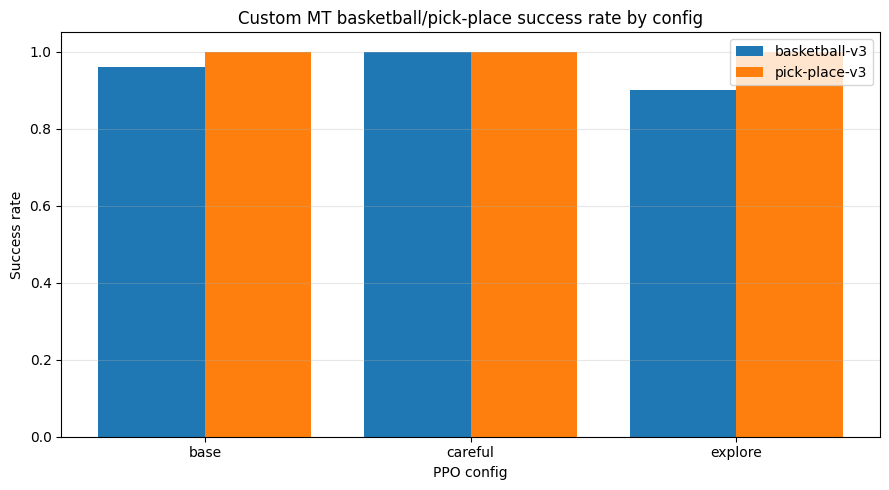

In [3]:
if summary is not None:
    success_pivot = summary.pivot_table(index='config', columns='task_name', values='success_rate')
    configs = list(success_pivot.index)
    tasks = list(success_pivot.columns)
    x = np.arange(len(configs))
    width = 0.8 / max(len(tasks), 1)

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, task in enumerate(tasks):
        ax.bar(x + (i - (len(tasks)-1)/2) * width, success_pivot[task], width, label=task)
    ax.set_title('Custom MT basketball/pick-place success rate by config')
    ax.set_xlabel('PPO config')
    ax.set_ylabel('Success rate')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Average return by config/task

task_name,basketball-v3,pick-place-v3
config,,
base,3632.396014,4554.925679
careful,4573.853442,4617.359016
explore,1787.814397,4125.376605


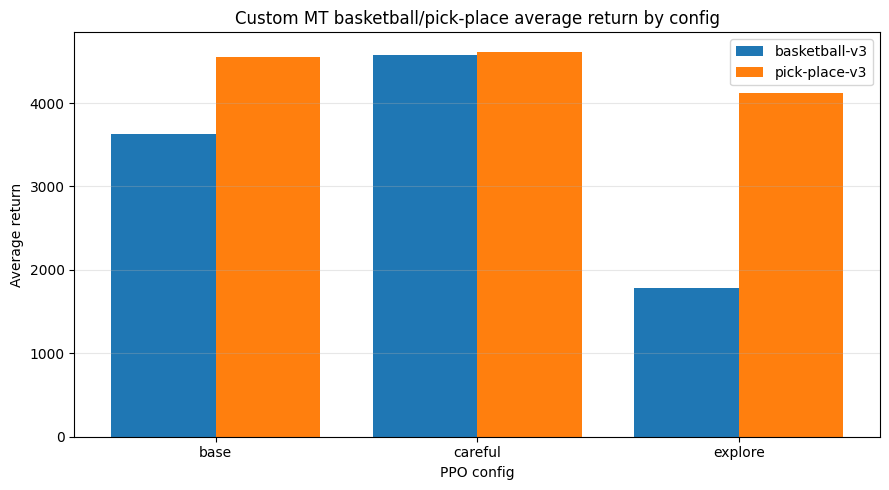

In [4]:
if summary is not None:
    return_pivot = summary.pivot_table(index='config', columns='task_name', values='avg_return')
    display(return_pivot)

    configs = list(return_pivot.index)
    tasks = list(return_pivot.columns)
    x = np.arange(len(configs))
    width = 0.8 / max(len(tasks), 1)

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, task in enumerate(tasks):
        ax.bar(x + (i - (len(tasks)-1)/2) * width, return_pivot[task], width, label=task)
    ax.set_title('Custom MT basketball/pick-place average return by config')
    ax.set_xlabel('PPO config')
    ax.set_ylabel('Average return')
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## First success step

Lower is better

task_name,basketball-v3,pick-place-v3
config,,
base,55.312500,49.88
careful,54.980000,42.22
explore,68.111111,42.10


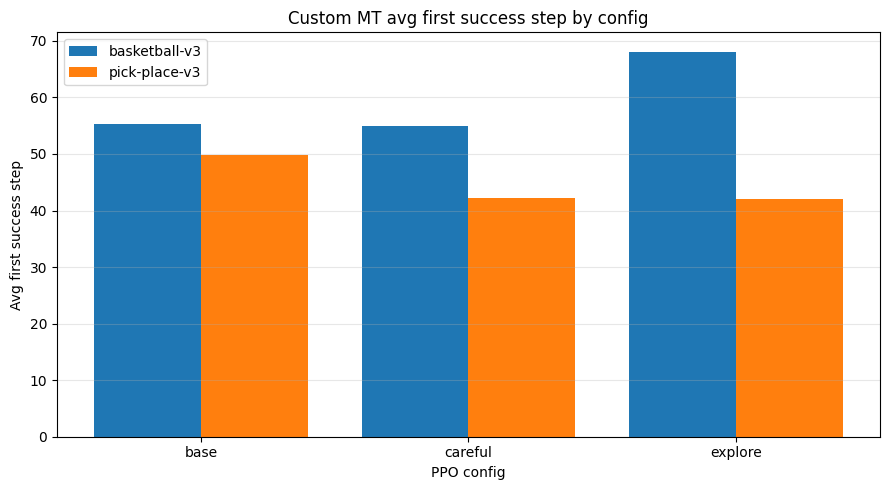

In [5]:
if summary is not None and 'avg_first_success_step' in summary.columns:
    fs_pivot = summary.pivot_table(index='config', columns='task_name', values='avg_first_success_step')
    display(fs_pivot)

    configs = list(fs_pivot.index)
    tasks = list(fs_pivot.columns)
    x = np.arange(len(configs))
    width = 0.8 / max(len(tasks), 1)

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, task in enumerate(tasks):
        ax.bar(x + (i - (len(tasks)-1)/2) * width, fs_pivot[task], width, label=task)
    ax.set_title('Custom MT avg first success step by config')
    ax.set_xlabel('PPO config')
    ax.set_ylabel('Avg first success step')
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No first-success-step column found.')

## 5. Per-seed breakdown

gia perissotera seeds meta

,config,task_name,eval_seed,success_rate,avg_return,std_return,avg_episode_length,avg_first_success_step,episodes
0,base,basketball-v3,1000,0.96,3632.396014,1659.094981,500.0,55.312500,50
1,base,pick-place-v3,1000,1.00,4554.925679,409.583544,500.0,49.880000,50
2,careful,basketball-v3,1000,1.00,4573.853442,10.001515,500.0,54.980000,50
3,careful,pick-place-v3,1000,1.00,4617.359016,127.590434,500.0,42.220000,50
4,explore,basketball-v3,1000,0.90,1787.814397,1890.032914,500.0,68.111111,50
5,explore,pick-place-v3,1000,1.00,4125.376605,1016.149159,500.0,42.100000,50


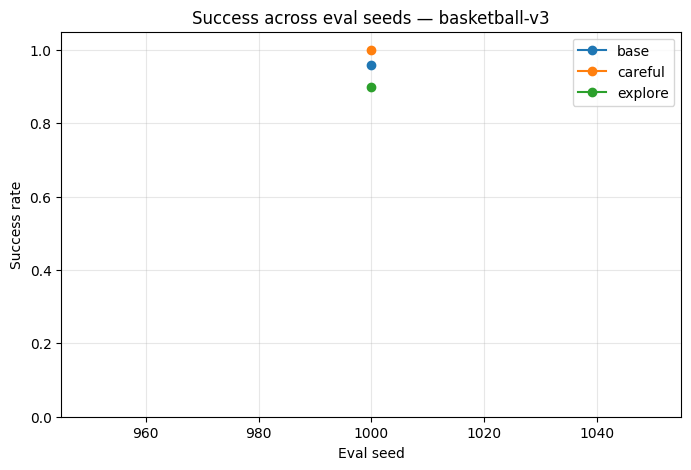

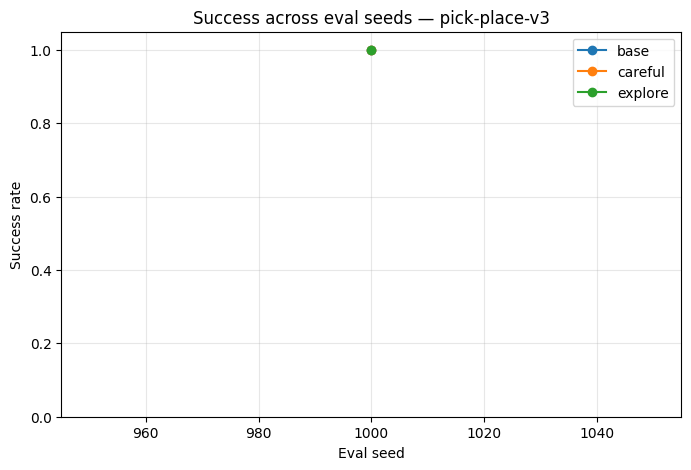

In [6]:
if by_seed is not None:
    display(by_seed.sort_values(['config', 'task_name', 'eval_seed']))

    for task in sorted(by_seed['task_name'].unique()):
        d_task = by_seed[by_seed['task_name'] == task]
        fig, ax = plt.subplots(figsize=(8, 5))
        for config in sorted(d_task['config'].unique()):
            d = d_task[d_task['config'] == config].sort_values('eval_seed')
            ax.plot(d['eval_seed'], d['success_rate'], marker='o', label=config)
        ax.set_title(f'Success across eval seeds — {task}')
        ax.set_xlabel('Eval seed')
        ax.set_ylabel('Success rate')
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()
else:
    print('No by-seed summary found.')

## Raw episode analysis

In [7]:
if raw is not None:
    display(raw.head())
    print(raw.columns.tolist())
    ep_summary = (
        raw.groupby(['config', 'task_name', 'eval_seed'])
        .agg(
            success_rate=('success', 'mean'),
            avg_return=('return', 'mean'),
            avg_length=('episode_length', 'mean'),
            avg_first_success_step=('first_success_step', 'mean'),
            episodes=('success', 'count'),
        )
        .reset_index()
    )
    display(ep_summary)
else:
    print('No raw episodes found.')

,config,task_idx,task_name,eval_seed,episode,success,return,episode_length,first_success_step
0,base,0,basketball-v3,1000,0,1.0,4537.918231,500,60.0
1,base,0,basketball-v3,1000,1,1.0,4578.161980,500,53.0
2,base,0,basketball-v3,1000,2,1.0,4595.210473,500,52.0
3,base,0,basketball-v3,1000,3,1.0,713.528742,500,64.0
4,base,0,basketball-v3,1000,4,1.0,4575.387926,500,57.0


['config', 'task_idx', 'task_name', 'eval_seed', 'episode', 'success', 'return', 'episode_length', 'first_success_step']


,config,task_name,eval_seed,success_rate,avg_return,avg_length,avg_first_success_step,episodes
0,base,basketball-v3,1000,0.96,3632.396014,500.0,55.312500,50
1,base,pick-place-v3,1000,1.00,4554.925679,500.0,49.880000,50
2,careful,basketball-v3,1000,1.00,4573.853442,500.0,54.980000,50
3,careful,pick-place-v3,1000,1.00,4617.359016,500.0,42.220000,50
4,explore,basketball-v3,1000,0.90,1787.814397,500.0,68.111111,50
5,explore,pick-place-v3,1000,1.00,4125.376605,500.0,42.100000,50


## Save figures

In [8]:
fig_dir = Path('basketball_pickplace_custom_mt_figures')
fig_dir.mkdir(parents=True, exist_ok=True)
saved = []

if summary is not None:
    success_pivot = summary.pivot_table(index='config', columns='task_name', values='success_rate')
    configs = list(success_pivot.index)
    tasks = list(success_pivot.columns)
    x = np.arange(len(configs))
    width = 0.8 / max(len(tasks), 1)
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, task in enumerate(tasks):
        ax.bar(x + (i - (len(tasks)-1)/2) * width, success_pivot[task], width, label=task)
    ax.set_title('Custom MT basketball/pick-place success rate by config')
    ax.set_xlabel('PPO config')
    ax.set_ylabel('Success rate')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    out = fig_dir / 'basketball_pickplace_success_by_config.png'
    fig.savefig(out, dpi=200, bbox_inches='tight')
    plt.close(fig)
    saved.append(out)

    return_pivot = summary.pivot_table(index='config', columns='task_name', values='avg_return')
    fig, ax = plt.subplots(figsize=(9, 5))
    for i, task in enumerate(tasks):
        ax.bar(x + (i - (len(tasks)-1)/2) * width, return_pivot[task], width, label=task)
    ax.set_title('Custom MT basketball/pick-place average return by config')
    ax.set_xlabel('PPO config')
    ax.set_ylabel('Average return')
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    out = fig_dir / 'basketball_pickplace_return_by_config.png'
    fig.savefig(out, dpi=200, bbox_inches='tight')
    plt.close(fig)
    saved.append(out)

print('Saved figures:')
for p in saved:
    print(' -', p)

Saved figures:
 - basketball_pickplace_custom_mt_figures\basketball_pickplace_success_by_config.png
 - basketball_pickplace_custom_mt_figures\basketball_pickplace_return_by_config.png
